In [1]:


import kagglehub

path = kagglehub.competition_download('constituency-war-room-grievance-triage-challenge')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/constituency-war-room-grievance-triage-challenge


In [2]:
!pip install torch>=2.0.0
!pip install transformers>=4.30.0
!pip install pandas>=1.5.0
!pip install  numpy>=1.24.0
!pip install  scikit-learn>=1.2.0
!pip install  tqdm>=4.65.0
!pip install matplotlib>=3.7.0
!pip install  seaborn>=0.12.0

In [3]:
import kagglehub
import os

# 1. Download the data
path = kagglehub.competition_download('constituency-war-room-grievance-triage-challenge')

# 2. See where it was saved
print(f"Data is stored at: {path}")

# 3. List the files inside that directory
files = os.listdir(path)
print("Files in the dataset:")
for file in files:
    print(f"- {file}")

Data is stored at: /kaggle/input/competitions/constituency-war-room-grievance-triage-challenge
Files in the dataset:
- sample_submission.csv
- train.csv
- test.csv


In [4]:
import pandas as pd

# Construct the exact path to the training data 
# (Update 'train.csv' to whatever file name os.listdir() showed you)
train_data = os.path.join(path, 'train.csv')
test_data =  os.path.join(path, 'test.csv')
sample_submission_df =  os.path.join(path, 'sample_submission.csv')



# Load and view the data
train_dataset = pd.read_csv(train_data)
test_dataset = pd.read_csv(test_data)
sample_submission = pd.read_csv(sample_submission_df)




In [5]:
train_dataset.head()

,id,subject,body,channel,district,complaint_history,label
0,G102149,Ambulance response time complaint,"Sir namaskara, The aspatre ward toilets are in...",whatsapp,Malligere,repeat_complaint,healthcare|routine
1,G103955,Sand lorries running at night,"Dear team, There have been five chain-snatchin...",whatsapp,Krishnapura,escalated,law_and_order|high
2,G106063,Urgent problem in our area,"Pranam sir, The main rasta through ward 4 in K...",janata_darshan,Ambalpet,first_time,roads_transport|high
3,G102374,Power cuts of 6+ hours daily in Chandpur,"Sir ji, This month's bills are three to four t...",field_visit,Ambalpet,escalated,electricity|routine
4,G105824,No drinking water in ward 4 for three days now,"Namaskara sir, The new apartment construction ...",field_visit,Devgiri,repeat_complaint,water_supply|routine


In [6]:
test_dataset.head()

,id,subject,body,channel,district,complaint_history
0,G105529,Crop insurance claim not settled since yesterday,"Pranam sir, Canal pani never reaches the tail-...",janata_darshan,Malligere,first_time
1,G105472,Street lights not working in MG layout,"Dear team, We request shifting of the electric...",facebook,Krishnapura,first_time
2,G103379,Bridge cnodition near ward 7,"Respected sir, School vans have stopped enteri...",field_visit,Rampura,repeat_complaint
3,G101632,Pipeline burst flooding the street,"Dear team, The water coming in our taps is bro...",field_visit,Ambalpet,first_time
4,G106613,Road udg up and left open for the past month,"Namaste, A trench dug for cable work near ward...",helpline_call,Ambalpet,escalated


In [7]:
sample_submission.head()

,id,label
0,G105529,roads_transport|routine
1,G105472,roads_transport|routine
2,G103379,roads_transport|routine
3,G101632,roads_transport|routine
4,G106613,roads_transport|routine


In [8]:
train_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4800 entries, 0 to 4799
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 4800 non-null   object
 1   subject            4800 non-null   object
 2   body               4800 non-null   object
 3   channel            4800 non-null   object
 4   district           4800 non-null   object
 5   complaint_history  4800 non-null   object
 6   label              4800 non-null   object
dtypes: object(7)
memory usage: 262.6+ KB


In [9]:
test_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 2000 non-null   object
 1   subject            2000 non-null   object
 2   body               2000 non-null   object
 3   channel            2000 non-null   object
 4   district           2000 non-null   object
 5   complaint_history  2000 non-null   object
dtypes: object(6)
memory usage: 93.9+ KB


In [10]:
sample_submission.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   object
 1   label   2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB


In [11]:
check_data1 = train_dataset[train_dataset['id'] == 'G105472']
print(check_data1)

check_data2 = test_dataset[test_dataset['id'] == 'G105472']
print(check_data2)



Empty DataFrame
Columns: [id, subject, body, channel, district, complaint_history, label]
Index: []
        id                                 subject  \
1  G105472  Street lights not working in MG layout   

                                                body   channel     district  \
1  Dear team, We request shifting of the electric...  facebook  Krishnapura   

  complaint_history  
1        first_time  


In [12]:
test_dataset[test_dataset['id'] == 'G105472']

,id,subject,body,channel,district,complaint_history
1,G105472,Street lights not working in MG layout,"Dear team, We request shifting of the electric...",facebook,Krishnapura,first_time


In [13]:
train_dataset = os.path.join(path, 'train.csv')
test_dataset =  os.path.join(path, 'test.csv')
sample_submission_df =  os.path.join(path, 'sample_submission.csv')

train = pd.read_csv(train_dataset)
test = pd.read_csv(test_dataset)
sample_submission = pd.read_csv(sample_submission_df)

In [14]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("PyTorch CUDA:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Capability:", torch.cuda.get_device_capability(0))
 

PyTorch: 2.10.0+cu128
CUDA available: True
PyTorch CUDA: 12.8
GPU: Tesla P100-PCIE-16GB
Capability: (6, 0)


/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 Tesla P100-PCIE-16GB which is of cuda capability 6.0.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (7.0) - (12.0)
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  queued_call()
/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:435: UserWarning: 
Tesla P100-PCIE-16GB with CUDA capability sm_60 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_70 sm_75 sm_80 sm_86 sm_90 sm_100 sm_120.
If you want to use the Tesla P100-PCIE-16GB GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  queued_call()


In [15]:
import os
import sys
import json
import numpy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [16]:
# Check GPU
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla P100-PCIE-16GB
GPU memory: 17.1 GB


In [17]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\nTrain columns:", train.columns.tolist())
print("\nFirst row:")
print(train.iloc[0])


Train shape: (4800, 7)
Test shape: (2000, 6)

Train columns: ['id', 'subject', 'body', 'channel', 'district', 'complaint_history', 'label']

First row:
id                                                             G102149
subject                              Ambulance response time complaint
body                 Sir namaskara, The aspatre ward toilets are in...
channel                                                       whatsapp
district                                                     Malligere
complaint_history                                     repeat_complaint
label                                               healthcare|routine
Name: 0, dtype: object


In [18]:
# Label analysis
train['dept'] = train['label'].apply(lambda x: x.split('|')[0])
train['urgency'] = train['label'].apply(lambda x: x.split('|')[1])

In [19]:
print("Department distribution:")
print(train['dept'].value_counts())
print("\nUrgency distribution:")
print(train['urgency'].value_counts())
print("\nCombined label distribution (top 15):")
print(train['label'].value_counts().head(15))

Department distribution:
dept
roads_transport           771
water_supply              663
welfare_schemes           648
electricity               605
healthcare                581
agriculture_irrigation    532
law_and_order             528
education                 472
Name: count, dtype: int64

Urgency distribution:
urgency
routine     2175
high        1756
critical     869
Name: count, dtype: int64

Combined label distribution (top 15):
label
roads_transport|routine           344
electricity|routine               308
water_supply|routine              293
roads_transport|high              288
welfare_schemes|high              268
healthcare|routine                260
welfare_schemes|routine           259
agriculture_irrigation|routine    258
water_supply|high                 242
law_and_order|routine             241
healthcare|high                   220
education|routine                 212
electricity|high                  196
law_and_order|high                193
agriculture_irrigat

In [20]:
# Text length analysis
train['text_len'] = train['body'].apply(len)
train['word_count'] = train['body'].apply(lambda x: len(str(x).split()))

In [21]:
print("Text length stats:")
print(train['text_len'].describe())
print("\nWord count stats:")
print(train['word_count'].describe())

Text length stats:
count    4800.000000
mean      312.301042
std        94.834682
min       135.000000
25%       243.000000
50%       292.000000
75%       373.000000
max       638.000000
Name: text_len, dtype: float64

Word count stats:
count    4800.000000
mean       53.479792
std        16.669283
min        21.000000
25%        41.000000
50%        50.000000
75%        64.000000
max       111.000000
Name: word_count, dtype: float64


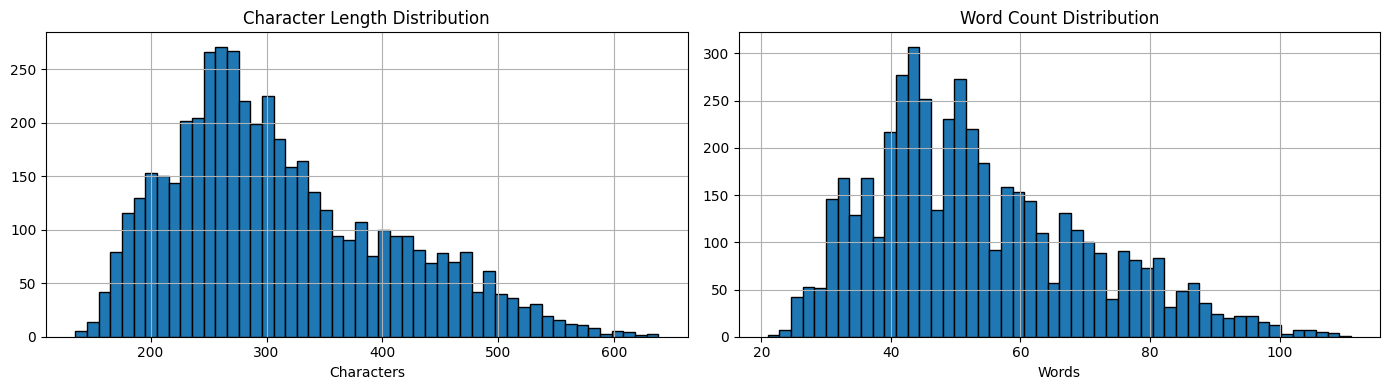

In [22]:
# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
train['text_len'].hist(bins=50, ax=axes[0], edgecolor='black')
axes[0].set_title('Character Length Distribution')
axes[0].set_xlabel('Characters')
train['word_count'].hist(bins=50, ax=axes[1], edgecolor='black')
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Words')
plt.tight_layout()
# plt.savefig('text_length_dist.png', dpi=150)
plt.show()

In [23]:
import re

class GrievanceTextProcessor:
    """Preprocesses code-mixed grievance text."""

    FILLER_WORDS = {
        'sir', 'namaskara', 'namaste', 'pranam', 'ji', 'saheb', 'madam',
        'dear', 'team', 'please', 'kindly', 'request', 'thank', 'thanks',
        'urgent', 'immediately', 'asap', 'soon', 'quickly',
    }

    CATEGORY_KEYWORDS = {
        'roads_transport': ['road', 'rasta', 'street', 'highway', 'bridge', 'pothole', 'traffic', 
                            'bus', 'auto', 'vehicle', 'accident', 'signal', 'footpath', 'drain'],
        'water_supply': ['water', 'paani', 'neeru', 'tap', 'pipeline', 'borewell', 'tanker', 
                         'drinking', 'supply', 'shortage', 'leakage', 'pollution'],
        'electricity': ['power', 'current', 'bijli', 'vijjut', 'transformer', 'wire', 'pole',
                        'outage', 'bill', 'meter', 'connection', 'generator', 'solar'],
        'healthcare': ['hospital', 'aspatre', 'doctor', 'daktar', 'medicine', 'ambulance',
                       'patient', 'fever', 'disease', 'clinic', 'health', 'treatment'],
        'education': ['school', 'shale', 'college', 'student', 'teacher', 'master',
                      'exam', 'result', 'admission', 'fee', 'books', 'midday meal'],
        'welfare_schemes': ['ration', 'pension', 'scheme', 'yojane', 'subsidy', 'card',
                            'aadhar', 'benefit', 'eligibility', 'application', 'approval'],
        'law_and_order': ['police', 'theft', 'chain snatching', 'robbery', 'crime', 'case',
                          'complaint', 'fir', 'court', 'lawyer', 'violence', 'safety'],
        'agriculture_irrigation': ['farm', 'kheti', 'crop', 'water canal', 'irrigation', 
                                   'fertilizer', 'seed', 'pest', 'land', 'harvest', 'mandi']
    }

    URGENCY_KEYWORDS = {
        'critical': ['death', 'dying', 'emergency', 'accident', 'fire', 'collapse', 
                     'flood', 'danger', 'injured', 'unconscious', 'poisoning'],
        'high': ['no supply', 'broken', 'stopped', 'three days', 'one week', 'children suffering',
                 'elderly', 'pregnant', 'school closed', 'hospital closed'],
        'routine': ['application', 'pending', 'request', 'suggestion', 'improve', 'quality',
                    'cleaning', 'maintenance', 'information', 'clarification']
    }

    def __init__(self):
        self.patterns = {
            'repeat_chars': re.compile(r'(.)\1{2,}'),
            'laughter': re.compile(r'\b(haha|hehe|lol|lmao|rofl)\b'),
            'mentions': re.compile(r'@\w+'),
            'urls': re.compile(r'http\S+|www\.\S+'),
            'phone': re.compile(r'\b\d{10}\b'),
            'extra_spaces': re.compile(r'\s+'),
        }

    def normalize(self, text):
        if not isinstance(text, str):
            text = str(text)
        text = text.lower().strip()
        text = self.patterns['repeat_chars'].sub(r'\1\1', text)
        text = self.patterns['urls'].sub('', text)
        text = self.patterns['mentions'].sub('', text)
        text = self.patterns['phone'].sub('<PHONE>', text)
        text = self.patterns['laughter'].sub('<LAUGH>', text)
        text = re.sub(r'[^a-zA-Z0-9\s\.\?\!,\-]', ' ', text)
        text = self.patterns['extra_spaces'].sub(' ', text)
        return text.strip()

    def extract_features(self, text):
        words = text.split()
        clean_words = [w for w in words if w not in self.FILLER_WORDS]
        has_devanagari = any('\u0900' <= c <= '\u097f' for c in text)

        return {
            'word_count': len(words),
            'clean_word_count': len(clean_words),
            'has_hindi': int(has_devanagari),
            'exclamation_count': text.count('!'),
            'question_count': text.count('?'),
            'caps_ratio': round(sum(1 for c in text if c.isupper()) / max(len(text), 1), 3),
            'time_refs': len(re.findall(r'\b(daily|weekly|monthly|today|yesterday|tomorrow|\d+\s*(day|week|month|hour))\b', text)),
            'numeric_refs': len(re.findall(r'\b\d+\+?\s*(hour|day|week|month|year|km|meter|rupee|rs)\b', text)),
            'negation_count': len(re.findall(r'\b(no|not|never|without|missing|lack|absent)\b', text)),
        }

    def keyword_score(self, text):
        text_lower = text.lower()
        scores = {}
        for cat, keywords in self.CATEGORY_KEYWORDS.items():
            scores[f'kw_{cat}'] = sum(1 for kw in keywords if kw in text_lower)
        for urg, keywords in self.URGENCY_KEYWORDS.items():
            scores[f'kw_{urg}'] = sum(1 for kw in keywords if kw in text_lower)
        return scores

    def process(self, text):
        clean = self.normalize(text)
        features = self.extract_features(clean)
        kw_scores = self.keyword_score(clean)
        return clean, features, kw_scores


In [24]:

# Process all texts
processor = GrievanceTextProcessor()

print("Processing train texts...")
train_clean, train_features, train_kw = [], [], []
for text in tqdm(train['body']):
    c, f, k = processor.process(text)
    train_clean.append(c)
    train_features.append(f)
    train_kw.append(k)

print("Processing test texts...")
test_clean, test_features, test_kw = [], [], []
for text in tqdm(test['body']):
    c, f, k = processor.process(text)
    test_clean.append(c)
    test_features.append(f)
    test_kw.append(k)

train['clean_body'] = train_clean
test['clean_body'] = test_clean

print("\nOriginal:")
print(train['body'].iloc[0][:200])
print("\nCleaned:")
print(train['clean_body'].iloc[0][:200])

Processing train texts...


100%|██████████| 4800/4800 [00:00<00:00, 5758.77it/s]


Processing test texts...


100%|██████████| 2000/2000 [00:00<00:00, 5778.20it/s]


Original:
Sir namaskara, The aspatre ward toilets are in bad condition and attendants are forced to go outside. Requesting maintenance staff be assigned. The previous complaint number I was given never got a re

Cleaned:
sir namaskara, the aspatre ward toilets are in bad condition and attendants are forced to go outside. requesting maintenance staff be assigned. the previous complaint number i was given never got a re


In [25]:
train['dept_label'] = train['dept']
train['urgency_label'] = train['urgency']

dept_encoder = LabelEncoder()
urgency_encoder = LabelEncoder()

train['dept_encoded'] = dept_encoder.fit_transform(train['dept_label'])
train['urgency_encoded'] = urgency_encoder.fit_transform(train['urgency_label'])

DEPARTMENTS = dept_encoder.classes_.tolist()
URGENCY_LEVELS = urgency_encoder.classes_.tolist()

print("Departments:", DEPARTMENTS)
print("Urgency levels:", URGENCY_LEVELS)
print("\nEncoded example:", train[['dept_label', 'dept_encoded', 'urgency_label', 'urgency_encoded']].iloc[0].to_dict())


Departments: ['agriculture_irrigation', 'education', 'electricity', 'healthcare', 'law_and_order', 'roads_transport', 'water_supply', 'welfare_schemes']
Urgency levels: ['critical', 'high', 'routine']

Encoded example: {'dept_label': 'healthcare', 'dept_encoded': 3, 'urgency_label': 'routine', 'urgency_encoded': 2}


In [26]:
class GrievanceClassifier(nn.Module):
    def __init__(self, model_name="xlm-roberta-base", num_departments=8, num_urgency=3, dropout=0.3):
        super().__init__()
        self.config = AutoModel.from_pretrained(model_name).config
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.config.hidden_size

        self.shared = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.GELU(),
            nn.LayerNorm(hidden_size // 2),
            nn.Dropout(dropout / 2),
        )

        self.dept_classifier = nn.Sequential(
            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_size // 4, num_departments)
        )

        self.urgency_classifier = nn.Sequential(
            nn.Linear(hidden_size // 2, hidden_size // 4),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_size // 4, num_urgency)
        )

    def forward(self, input_ids, attention_mask, dept_labels=None, urgency_labels=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = outputs.last_hidden_state[:, 0]
        shared_repr = self.shared(pooled)

        dept_logits = self.dept_classifier(shared_repr)
        urgency_logits = self.urgency_classifier(shared_repr)

        loss = None
        if dept_labels is not None and urgency_labels is not None:
            dept_loss = nn.CrossEntropyLoss()(dept_logits, dept_labels)
            urgency_loss = nn.CrossEntropyLoss()(urgency_logits, urgency_labels)
            loss = dept_loss + 0.4 * urgency_loss

        return {
            'loss': loss,
            'dept_logits': dept_logits,
            'urgency_logits': urgency_logits
        }

class GrievanceDataset(torch.utils.data.Dataset):
    def __init__(self, texts, dept_labels, urgency_labels, tokenizer, max_len=256):
        self.texts = texts
        self.dept_labels = dept_labels
        self.urgency_labels = urgency_labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text, max_length=self.max_len, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'dept_label': torch.tensor(self.dept_labels[idx], dtype=torch.long),
            'urgency_label': torch.tensor(self.urgency_labels[idx], dtype=torch.long)
        }

print("Model architecture defined.")


Model architecture defined.


In [27]:
def compute_class_weights(labels):
    counts = np.bincount(labels)
    weights = 1.0 / (counts + 1)
    weights = weights / weights.sum() * len(weights)
    return torch.tensor(weights, dtype=torch.float)

def evaluate_model(model, dataloader, device):
    model.eval()
    dept_preds, dept_true = [], []
    urgency_preds, urgency_true = [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids, attention_mask)

            dept_preds.extend(torch.argmax(outputs['dept_logits'], dim=1).cpu().numpy())
            urgency_preds.extend(torch.argmax(outputs['urgency_logits'], dim=1).cpu().numpy())
            dept_true.extend(batch['dept_label'].numpy())
            urgency_true.extend(batch['urgency_label'].numpy())

    dept_f1 = f1_score(dept_true, dept_preds, average='weighted')
    urgency_f1 = f1_score(urgency_true, urgency_preds, average='weighted')
    combined_f1 = (dept_f1 + urgency_f1) / 2

    dept_acc = accuracy_score(dept_true, dept_preds)
    urgency_acc = accuracy_score(urgency_true, urgency_preds)

    return {
        'dept_f1': dept_f1, 'urgency_f1': urgency_f1, 'combined_f1': combined_f1,
        'dept_acc': dept_acc, 'urgency_acc': urgency_acc,
        'dept_preds': dept_preds, 'urgency_preds': urgency_preds,
        'dept_true': dept_true, 'urgency_true': urgency_true
    }

# %% [code] {"execution": {"iopub.status.busy": "2026-08-25T00:00:00.000Z", "iopub.execute_input": "2026-08-25T00:00:00.000Z"}}
MODEL_NAME = "xlm-roberta-base"
BATCH_SIZE = 8
EPOCHS = 5
LR = 2e-5
MAX_LEN = 256
N_SPLITS = 2

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device='cpu'
print(f"Using device: {device}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
texts = train['clean_body'].tolist()
dept_labels = train['dept_encoded'].values
urgency_labels = train['urgency_encoded'].values

# Stratified K-Fold on department (more stable than 24 classes)
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

fold_results = []
model_paths = []

for fold, (train_idx, val_idx) in enumerate(skf.split(texts, dept_labels)):
    print(f"\n{'='*60}")
    print(f"Fold {fold + 1}/{N_SPLITS}")
    print(f"{'='*60}")

    tr_texts = [texts[i] for i in train_idx]
    tr_depts = dept_labels[train_idx]
    tr_urgency = urgency_labels[train_idx]

    val_texts = [texts[i] for i in val_idx]
    val_depts = dept_labels[val_idx]
    val_urgency = urgency_labels[val_idx]

    train_dataset = GrievanceDataset(tr_texts, tr_depts, tr_urgency, tokenizer, MAX_LEN)
    val_dataset = GrievanceDataset(val_texts, val_depts, val_urgency, tokenizer, MAX_LEN)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2)

    model = GrievanceClassifier(MODEL_NAME).to(device)

    dept_weights = compute_class_weights(tr_depts).to(device)
    urgency_weights = compute_class_weights(tr_urgency).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps
    )

    best_f1 = 0.0

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            dept_l = batch['dept_label'].to(device)
            urgency_l = batch['urgency_label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask, dept_l, urgency_l)

            dept_loss = nn.CrossEntropyLoss(weight=dept_weights)(outputs['dept_logits'], dept_l)
            urgency_loss = nn.CrossEntropyLoss(weight=urgency_weights)(outputs['urgency_logits'], urgency_l)
            loss = dept_loss + 0.4 * urgency_loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        # Validation
        val_metrics = evaluate_model(model, val_loader, device)

        print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, "
              f"Val F1={val_metrics['combined_f1']:.4f} "
              f"(D={val_metrics['dept_f1']:.4f}, U={val_metrics['urgency_f1']:.4f})")

        if val_metrics['combined_f1'] > best_f1:
            best_f1 = val_metrics['combined_f1']
            model_path = f'best_model_fold_{fold}.pt'
            torch.save({
                'model_state_dict': model.state_dict(),
                'metrics': val_metrics,
                'fold': fold
            }, model_path)
            print(f"  -> Saved new best model (F1={best_f1:.4f})")

    fold_results.append(best_f1)
    model_paths.append(f'best_model_fold_{fold}.pt')
    print(f"Fold {fold+1} Best F1: {best_f1:.4f}")

# %% [code] {"execution": {"iopub.status.busy": "2026-08-25T00:00:00.000Z", "iopub.execute_input": "2026-08-25T00:00:00.000Z"}}
print(f"\n{'='*60}")
print("Cross-Validation Summary")
print(f"{'='*60}")
print(f"Mean F1: {np.mean(fold_results):.4f} (+/- {np.std(fold_results):.4f})")
print(f"All folds: {[f'{f:.4f}' for f in fold_results]}")


Using device: cpu


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Epoch 3: Loss=0.1146, Val F1=1.0000 (D=1.0000, U=1.0000)
  -> Saved new best model (F1=1.0000)


Epoch 4/5: 100%|██████████| 300/300 [44:12<00:00,  8.84s/it]


Epoch 4: Loss=0.0367, Val F1=1.0000 (D=1.0000, U=1.0000)


Epoch 5/5: 100%|██████████| 300/300 [43:37<00:00,  8.73s/it]


Epoch 5: Loss=0.0245, Val F1=1.0000 (D=1.0000, U=1.0000)
Fold 2 Best F1: 1.0000

Cross-Validation Summary
Mean F1: 1.0000 (+/- 0.0000)
All folds: ['1.0000', '1.0000']


Best fold: 1 (F1 = 1.0000)

Validation metrics:
  dept_f1: 1.0000
  urgency_f1: 1.0000
  combined_f1: 1.0000
  dept_acc: 1.0000
  urgency_acc: 1.0000


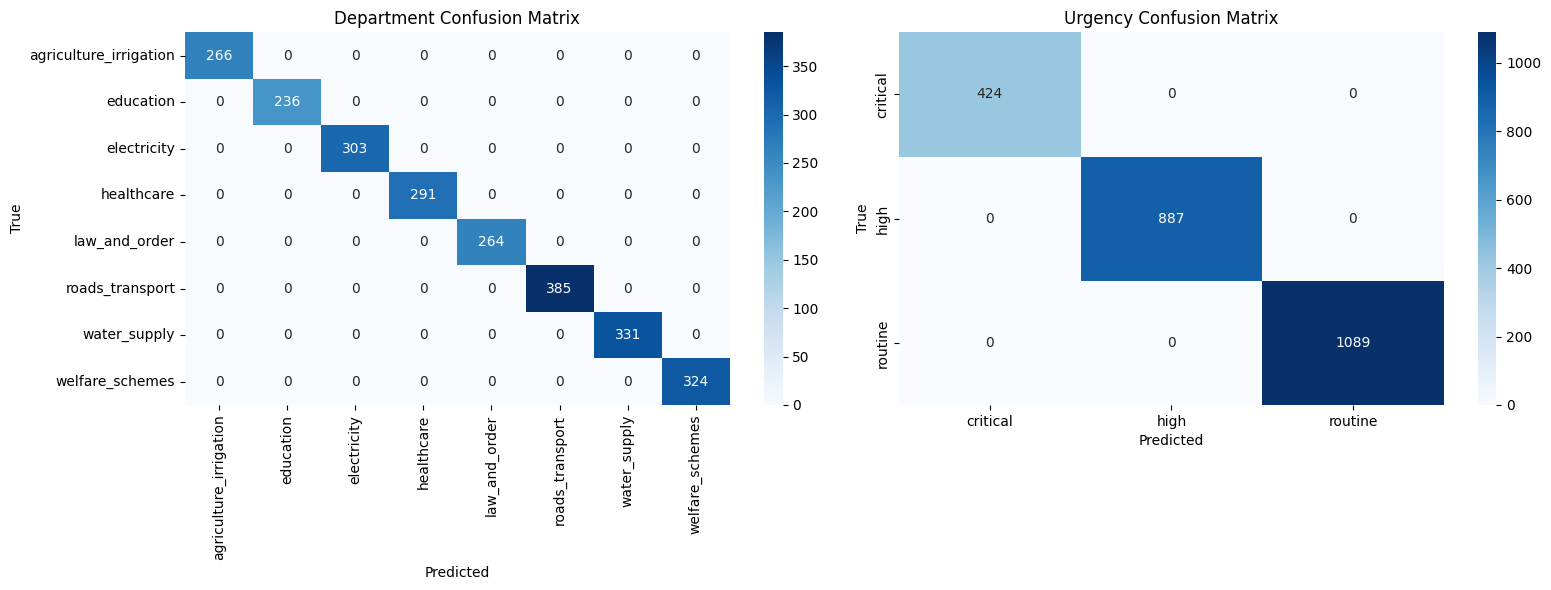

In [28]:
best_fold = np.argmax(fold_results)
print(f"Best fold: {best_fold + 1} (F1 = {fold_results[best_fold]:.4f})")

# checkpoint = torch.load(model_paths[best_fold])
checkpoint = torch.load(
    model_paths[best_fold],
    weights_only=False
)
print("\nValidation metrics:")
for k, v in checkpoint['metrics'].items():
    if not isinstance(v, list):
        print(f"  {k}: {v:.4f}")

# Confusion matrices
dept_preds = checkpoint['metrics']['dept_preds']
dept_true = checkpoint['metrics']['dept_true']
urgency_preds = checkpoint['metrics']['urgency_preds']
urgency_true = checkpoint['metrics']['urgency_true']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_dept = confusion_matrix(dept_true, dept_preds)
sns.heatmap(cm_dept, annot=True, fmt='d', cmap='Blues', 
            xticklabels=DEPARTMENTS, yticklabels=DEPARTMENTS, ax=axes[0])
axes[0].set_title('Department Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

cm_urg = confusion_matrix(urgency_true, urgency_preds)
sns.heatmap(cm_urg, annot=True, fmt='d', cmap='Blues',
            xticklabels=URGENCY_LEVELS, yticklabels=URGENCY_LEVELS, ax=axes[1])
axes[1].set_title('Urgency Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
# plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

In [29]:
def predict_ensemble(test_texts, model_paths, tokenizer, device, batch_size=32):
    """Ensemble predictions from all fold models."""

    dummy_depts = [0] * len(test_texts)
    dummy_urgency = [0] * len(test_texts)

    test_dataset = GrievanceDataset(test_texts, dummy_depts, dummy_urgency, tokenizer, MAX_LEN)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    all_models = []
    for path in model_paths:
        model = GrievanceClassifier(MODEL_NAME).to(device)
        # checkpoint = torch.load(path, map_location=device)
        checkpoint = torch.load(
            path,
            map_location=device,
            # map_location="cpu",
            weights_only=False
        )
        
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()
        all_models.append(model)

    all_dept_probs = []
    all_urgency_probs = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Predicting"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            batch_dept_probs = []
            batch_urgency_probs = []

            for model in all_models:
                outputs = model(input_ids, attention_mask)
                batch_dept_probs.append(torch.softmax(outputs['dept_logits'], dim=1).cpu().numpy())
                batch_urgency_probs.append(torch.softmax(outputs['urgency_logits'], dim=1).cpu().numpy())

            avg_dept = np.mean(batch_dept_probs, axis=0)
            avg_urgency = np.mean(batch_urgency_probs, axis=0)

            all_dept_probs.append(avg_dept)
            all_urgency_probs.append(avg_urgency)

    dept_probs = np.concatenate(all_dept_probs, axis=0)
    urgency_probs = np.concatenate(all_urgency_probs, axis=0)

    dept_preds = np.argmax(dept_probs, axis=1)
    urgency_preds = np.argmax(urgency_probs, axis=1)

    labels = []
    for d, u in zip(dept_preds, urgency_preds):
        labels.append(f"{DEPARTMENTS[d]}|{URGENCY_LEVELS[u]}")

    return labels, dept_probs, urgency_probs

# Generate predictions
test_texts = test['clean_body'].tolist()
predicted_labels, dept_probs, urgency_probs = predict_ensemble(
    test_texts, model_paths, tokenizer, device
)

# Create submission
submission = pd.DataFrame({
    'id': test['id'],
    'label': predicted_labels
})

submission.to_csv('submission.csv', index=False)
print(f"Submission saved! Shape: {submission.shape}")
print("\nLabel distribution:")
print(submission['label'].value_counts().head(15))

# %% [code] {"execution": {"iopub.status.busy": "2026-08-25T00:00:00.000Z", "iopub.execute_input": "2026-08-25T00:00:00.000Z"}}
# Confidence analysis
confidence_scores = [(d.max() + u.max()) / 2 for d, u in zip(dept_probs, urgency_probs)]
print(f"\nConfidence stats:")
print(f"  Mean: {np.mean(confidence_scores):.3f}")
print(f"  Min: {np.min(confidence_scores):.3f}")
print(f"  Max: {np.max(confidence_scores):.3f}")

# Low confidence predictions
low_conf_idx = np.argsort(confidence_scores)[:10]
print("\nLowest confidence predictions:")
for idx in low_conf_idx:
    print(f"  {submission.iloc[idx]['id']}: {submission.iloc[idx]['label']} (conf={confidence_scores[idx]:.3f})")
    print(f"    Text: {test['body'].iloc[idx][:100]}...")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Predicting: 100%|██████████| 63/63 [13:38<00:00, 12.99s/it]


Submission saved! Shape: (2000, 2)

Label distribution:
label
roads_transport|routine           144
electricity|routine               128
water_supply|routine              122
roads_transport|high              120
welfare_schemes|high              111
healthcare|routine                109
welfare_schemes|routine           108
agriculture_irrigation|routine    108
water_supply|high                 101
law_and_order|routine             100
healthcare|high                    92
education|routine                  88
electricity|high                   82
law_and_order|high                 81
agriculture_irrigation|high        75
Name: count, dtype: int64

Confidence stats:
  Mean: 0.927
  Min: 0.637
  Max: 0.964

Lowest confidence predictions:
  G101199: agriculture_irrigation|routine (conf=0.637)
    Text: Pranam sir, The osil-tseting van that was to visit Devgiri never came, and the support price centre ...
  G101695: water_supply|high (conf=0.839)
    Text: Namaskara sir, Our colony in A

In [30]:
import pandas as pd

sample = pd.read_csv("/kaggle/input/competitions/constituency-war-room-grievance-triage-challenge/sample_submission.csv")
submission = pd.read_csv("/kaggle/working/submission.csv")

assert len(submission) == len(sample), (
    f"Wrong number of rows: {len(submission)} vs {len(sample)}"
)
assert list(submission.columns) == list(sample.columns), (
    f"Wrong columns: {submission.columns.tolist()} vs {sample.columns.tolist()}"
)
assert submission.notna().all().all(), "Submission contains missing values"

print("Submission validation passed!")


Submission validation passed!
